# 데이터 시각화 

metplotlib 라이브러리 사용

>metpolitlib란? Python에서 그래프, 차트 등을 그리는데 사용하는 라이브러리

In [ ]:
%pip install matplotlib

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한글이 깨지는 경우, 운영체제 맞게 한글 폰트 지정
if platform.system() == "Windows":
    #윈도우: 맑은 고딕
    matplotlib.rc("font", family = "Malgun Gothic")
elif platform.system() == "Darwin":
    #맥: 애플 고딕
    matplotlib.rc("font", family = "AppleGothic")
else:
    #리눅스: 나눔 고딕
    matplotlib.rc("font", family = "NanumGothic")

# 마이너스 기호 깨짐 방지    
matplotlib.rc("axes", unicode_minus=False)

print("matplotlib 준비완료")
print("현재 os:", platform.system())

# Line Chart (꺾은선 그래프)

-> 시간에 따른 변화를 보여줄 때, 가장 많이 사용함

In [ ]:
# 월 평균 기온 데이터
months = [1 ,2 ,3 ,4 ,5 ,6 ,7 ,8 ,9 ,10,11,12]
temps =  [-5,1 ,5 ,14,19,25,30,40,30,15,8 ,0 ]

# 그래프 그리는 순서:
# 1. plt.figure(도화지) - figsize 는 크기(가로, 세로)
plt.figure(figsize=(10,5))
# 2. 꺾은선 그래프 그리기 - marker는 데이터 위치에 표시되는 점, color는 테마
plt.plot(months, temps, marker="o", color="tomato")
# 3. 제목과 축 라벨(레이블) 설정
plt.title("월 평균 기온")
plt.xlabel("월")
plt.ylabel("기온")
# 4. 보조선(Grid)  추가
plt.grid(True)
# 5. 그래프 출력
plt.show

# 막대 그래프

항목별 값을 비교할때 사용

In [ ]:
# 과목별 평균 점수 데이터
subjects    = ["국어", "수학", "영어", "과학", "사회"]
avg_scores  = [78    , 82   , 74    , 88    , 40   ]

plt.figure(figsize=(8,5))
plt.bar(subjects, avg_scores, color="steelblue")
plt.title("과목별 평균 점수")
plt.xlabel("과목")
plt.ylabel("점수")
plt.ylim(0, 100) # Y축 범위 지정(0~100)
plt.grid(axis="y")  #Y축 보조선
plt.text(0,80,"테스트", ha="center") #plt.text(x좌표,y좌표,표시할 텍스트, 수평 정렬(left/center/right))
plt.show()

## 문제

과목별 평균 점수를 막대 그래프 상단에 표시하기

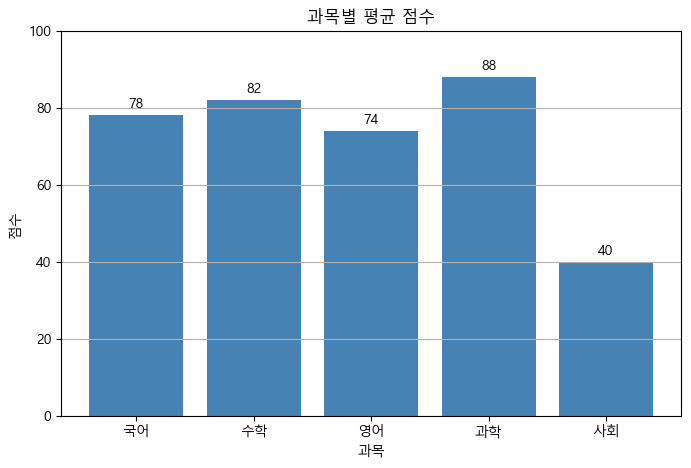

In [34]:
import matplotlib.pyplot as plt
import matplotlib
import platform

# 한글 폰트 설정 (이전 코드 동일)
if platform.system() == "Windows":
    matplotlib.rc("font", family = "Malgun Gothic")
elif platform.system() == "Darwin":
    matplotlib.rc("font", family = "AppleGothic")
else:
    matplotlib.rc("font", family = "NanumGothic")
matplotlib.rc("axes", unicode_minus=False)

# 과목별 평균 점수 데이터
subjects    = ["국어", "수학", "영어", "과학", "사회"]
avg_scores  = [78    , 82   , 74    , 88    , 40   ]

plt.figure(figsize=(8,5))
plt.bar(subjects, avg_scores, color="steelblue")
plt.title("과목별 평균 점수")
plt.xlabel("과목")
plt.ylabel("점수")
plt.ylim(0, 100) 
plt.grid(axis="y")

# 💡 [핵심 코드] for문을 이용해 모든 막대 위에 텍스트 추가
for i in range(len(subjects)):
    # x좌표: i (0부터 4까지)
    # y좌표: avg_scores[i] + 2 (막대 꼭대기에서 살짝 위로 띄우기 위해 +2)
    # 표시할 텍스트: str(avg_scores[i]) (숫자를 문자로 변환)
    plt.text(i, avg_scores[i] + 2, str(avg_scores[i]), ha="center")

plt.show()

## 산점도 (Scatter Plot)
두 수치 데이터 사이의 관계(상관관계)를 점으로 나타낸 그래프

> 머신러닝에서 특성(feature)간의 관계를 시각적으로 파악할때 사용
 

In [ ]:
# 공부 시간과 점수의 관계
study = [1 , 2 , 3 , 3 , 4 , 4 , 5 , 6 , 7 , 8 ]
score = [42, 52, 61, 75, 63, 78, 80, 85, 88, 95]

plt.figure(figsize=(8,5))
# s 매개변수는 점의 크기
plt.scatter(study, score, color="darkorange", s=80)
plt.title("공부 시간과 시험 점수의 관계")
plt.xlabel("공부시간(h)")
plt.ylabel("시험 점수")
plt.grid(True)
plt.show()

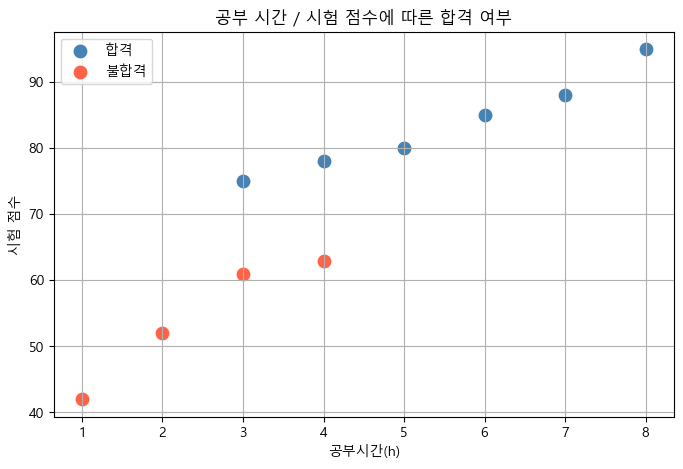

In [35]:
# 공부 시간과 점수에 대한 합격/불합격을 색으로 구분
# 70점 이상은 합격
study     = [1 , 2 , 3 , 3 , 4 , 4 , 5 , 6 , 7 , 8 ]
score     = [42, 52, 61, 75, 63, 78, 80, 85, 88, 95]
pass_fail = [0 , 0 , 0 , 1 , 0 , 1 , 1 , 1 , 1 , 1 ]

# 합격/불합격 분리
pass_study = [study[i] for i in range(len(pass_fail)) if pass_fail[i] == 1]
pass_score = [score[i] for i in range(len(pass_fail)) if pass_fail[i] == 1]
fail_study = [study[i] for i in range(len(pass_fail)) if pass_fail[i] == 0]
fail_score = [score[i] for i in range(len(pass_fail)) if pass_fail[i] == 0]

plt.figure(figsize=(8,5))

# 합격/불합격 데이터 산점도 (색상 및 범례 추가)
plt.scatter(pass_study, pass_score, color="steelblue", s=80, label="합격")
plt.scatter(fail_study, fail_score, color="tomato", s=80, label="불합격")

# s 매개변수는 점의 크기
plt.title("공부 시간 / 시험 점수에 따른 합격 여부")
plt.xlabel("공부시간(h)")
plt.ylabel("시험 점수")
plt.legend() # 범례
plt.grid(True)
plt.show()